In [1]:
import pandas as pd
import numpy as np

temp_pressure_df = pd.read_csv ("/content/polynomial_regression_data.csv")
temp_pressure_df

,sno,Temperature,Pressure
0,1,0.000000,0.000000e+00
1,2,1.010101,2.061220e-10
2,3,2.020202,1.648976e-09
3,4,3.030303,5.565295e-09
4,5,4.040404,1.319181e-08
...,...,...,...
95,96,95.959596,1.767239e-04
96,97,96.969697,1.823636e-04
97,98,97.979798,1.881220e-04
98,99,98.989899,1.940004e-04


In [4]:
temp_pressure_df.columns

Index(['sno', 'Temperature', 'Pressure'], dtype='object')

In [5]:
# Input - Temperature, Output -> Pressure
x = temp_pressure_df[["Temperature"]]
y = temp_pressure_df[["Pressure"]]

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 4)
x_poly = poly.fit_transform(x)

In [8]:
# PolynomialFeatures does not have a fit method for this purpose.
# The transform method was already called in the previous cell
# poly.fiit(x_poly, y)

In [10]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_poly, y)

LinearRegression()

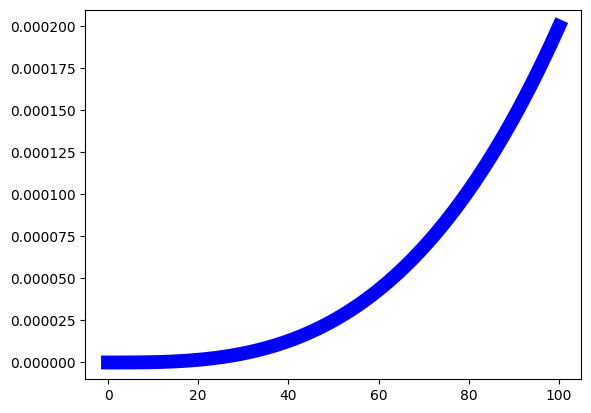

In [12]:
#Visualize the predictions
import matplotlib.pyplot as plt
plt.scatter(x, y, color = "red")
plt.plot(x, lin_reg.predict(poly.fit_transform(x)), linewidth = 10, color = "blue")

In [13]:
data = 110
pred = np.array([[data]])
lin_reg.predict(poly.fit_transform(pred))

array([[0.0002662]])

In [14]:
#Evaluate the model
from sklearn.metrics import r2_score
y_pred = lin_reg.predict(x_poly)
r2_score(y, y_pred)

1.0

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [16]:
df = pd.read_csv("/content/solar_power_output(in) (1).csv")
df.head()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
0,19.363503,75.852937,266.619636,5.190818,128.101772
1,33.767858,62.887709,587.710853,4.791819,290.911789
2,28.299849,44.762209,885.651252,0.256421,442.336390
3,24.966462,85.103602,759.002398,3.412478,380.261988
4,13.900466,74.778494,825.905033,3.801956,415.931953


In [17]:
x = df[['temperature', 'humidity', 'solar_irradiance','wind_speed']]
y = df['solar_power_output']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
# Predicting the solar output on the test set
y_pred = model.predict(X_test)
y_pred

array([145.57713107,  58.80813609, 162.02529474, 389.82145928,
       499.91950595, 201.02821571, 280.32773309, 343.94995965,
       207.65845172, 274.08855806, 270.4758993 ,  71.45181395,
       429.27171131, 474.93452179, 131.00879231, 488.72382533,
       351.97648481,  66.01156112, 286.53039282, 315.26996556,
       156.25649584, 217.68415496, 328.50926609, 456.09724416,
       224.59964917, 343.33441392, 258.65661936, 253.27035923,
       487.33886963, 488.13938701, 352.87341422, 139.35221978,
       486.24574421, 166.59050111, 443.99714231, 498.93693594,
       440.23818943, 184.21480103, 497.81182989, 239.22808164,
       345.26650268, 281.3410799 , 215.84679473, 472.53738058,
       105.19383875, 353.92961077, 132.62179773, 496.30985098,
       472.03357269, 464.32390433,  68.39576649, 337.05784427,
       271.45779666, 142.00782193, 330.57420012, 209.16463828,
       431.33413853, 460.52547819, 271.68335515, 148.17216827,
       322.32496319, 189.54364633, 148.80585847,  54.32

In [26]:
# Evaluate the model performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error:, {mse}")
print(f"R-squared:, {r2}")

Mean Squared Error:, 29.462345965626284
R-squared:, 0.9983255901418433


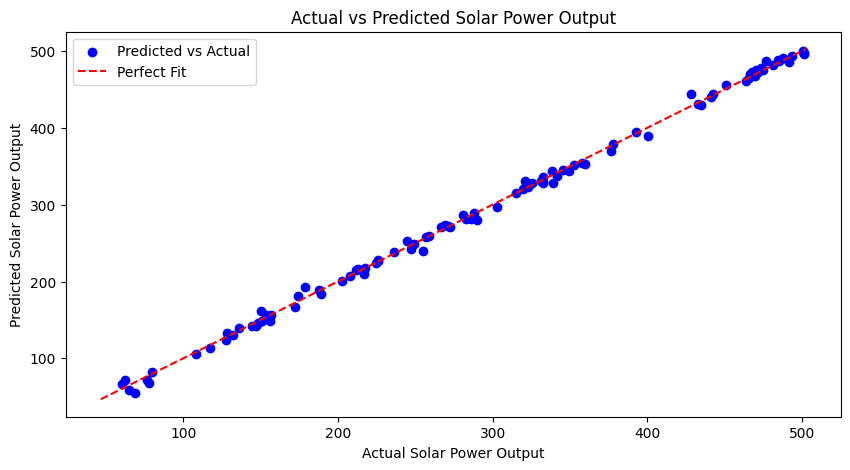

In [28]:
import matplotlib.pyplot as plt

#Scatter plot to comapre actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color = 'blue', label = 'Predicted vs Actual')
# Diagonal line for perfect prediction
plt.plot([y.min(), y.max()], [y.min(), y.max()], color = 'red', linestyle = '--', label = 'Perfect Fit')
plt.xlabel('Actual Solar Power Output')
plt.ylabel('Predicted Solar Power Output')
plt.title('Actual vs Predicted Solar Power Output')
plt.legend()
plt.show()

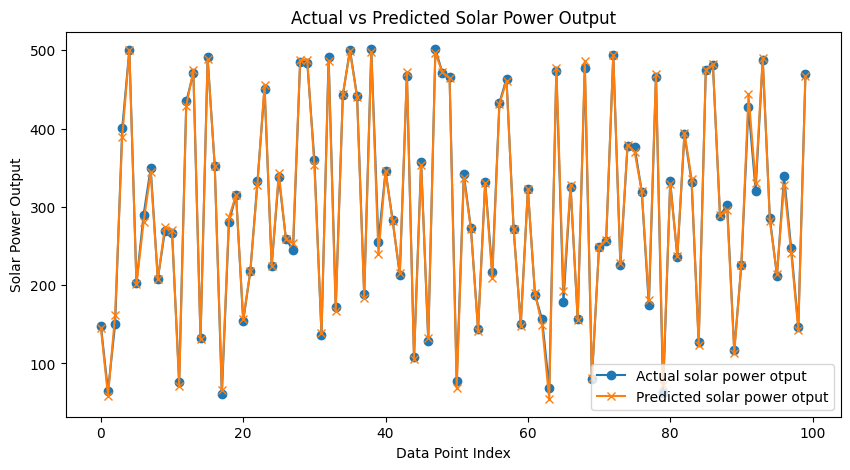

In [30]:
# Line Plot to show predictions and actual value
plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label = 'Actual solar power otput', marker='o')
plt.plot(range(len(y_test)), y_pred, label = 'Predicted solar power otput', marker='x')
plt.xlabel('Data Point Index')
plt.ylabel('Solar Power Output')
plt.title('Actual vs Predicted Solar Power Output')
plt.legend()
plt.show()

In [31]:
# save the trained model
joblib.dump(model, 'solar_power_output_model.pkl')

['solar_power_output_model.pkl']

In [32]:
#load the saved model

model = joblib.load('solar_power_output_model.pkl')

# New input data for prediction
#example input (temperature, hummidity, solar_irradiance, wind_speed)
new_data = np.array([[19.36, 75.85, 266.61, 5.19]])

# predict solar power output
predicted_output = model.predict(new_data)
print(f"Predicted Solar Power Output: {predicted_output[0]} watts")

Predicted Solar Power Output: 132.6167057310625 watts


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
import pandas as pd
import numpy as np


In [34]:
titanic_df = pd.read_csv("titanic.csv")
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
# Dropping ome column
titanic_df.drop(["PassengerId", "Name", "Ticket", "Cabin", "Fare", "Embarked"], axis = 1, inplace = True)
titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch
0,0,3,male,22.0,1,0
1,1,1,female,38.0,1,0
2,1,3,female,26.0,0,0
3,1,1,female,35.0,1,0
4,0,3,male,35.0,0,0
...,...,...,...,...,...,...
886,0,2,male,27.0,0,0
887,1,1,female,19.0,0,0
888,0,3,female,NaN,1,2
889,1,1,male,26.0,0,0
